# 🍎 FreshGuard | Notebook 02: Core Model Training

**Course:** Deep Learning · Section B · MBDS-SEP 25 · IE University

**Team:** Sebastião Clemente · Bassem El Halawani · Marco Ortiz Togashi · Jorge Luis Vildoso Pineda · Yaxin Wu

We don't just *pick* a CNN: we **prove** the architecture choice by running the same task through three models of increasing capacity on our own data:

| # | Model | Why we try it | Expected outcome |
|---|---|---|---|
| 1 | ANN on flattened pixels | Establish a floor with no spatial inductive bias | Underperforms: pixel order is lost |
| 2 | CNN from scratch | Add convolutions to learn spatial features | Better, but limited by dataset size |
| 3 | MobileNetV2 transfer learning | Reuse ImageNet features, fine-tune the top | Best: strong features + light adaptation |

Why not a Vision Transformer? ViT only overtakes CNNs when pretrained on ~100M+ images; our dataset has ~28k images, so CNN transfer learning is the right fit.

**Scope:** 20 classes = fresh/rotten across 10 produce types {apple, banana, orange, carrot, tomato, potato, cucumber, bell pepper, mango, strawberry}. Apple, banana, orange, and carrot are COCO-detectable, so the Stage-1 YOLO detector localizes them zero-shot; the other six use a center-crop fallback (Grad-CAM classification, no bounding box).

> Run on **Colab GPU** (Runtime > Change runtime type > T4).

## 0. Colab setup (run this first)

This cell recreates the run environment so **Run all** works end-to-end:

1. Checks for a GPU (training expects a T4: *Runtime > Change runtime type > GPU*).
2. Mounts Google Drive and points at the uploaded project folder.
3. Installs the pinned dependencies (`tensorflow==2.20.0`, the exact version the model was saved under).
4. Rebuilds the dataset, which is gitignored and not shipped with the repo.

The dataset rebuild requires Kaggle credentials, but won't crash the notebook if they're missing: the step is simply skipped and the evaluation cells use the pre-committed figures in `docs/figures/` instead. To build it, add your Kaggle key as a Colab secret (the key icon in the left bar) named `KAGGLE`, then re-run this cell.

> **Edit `REPO_DIR`** below to match where you uploaded the project folder in your Drive.

In [1]:
# === 0. Colab setup: GPU, dependencies, dataset ===
import os, sys, subprocess, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1) GPU check - training is slow without one
    gpu = subprocess.getoutput("nvidia-smi -L")
    print("GPU:", gpu if "GPU" in gpu else "NONE -- set Runtime > Change runtime type > T4")

    # 2) Mount Drive. EDIT this if your Drive folder has a different name.
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_FOLDER = "/content/drive/MyDrive/Deep_LearningB_GroupProject"

    # 3) Pin TF to the version the model was saved under (prevents the load crash)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tensorflow==2.20.0", "kagglehub", "ultralytics"], check=True)
else:
    DRIVE_FOLDER = str(Path.cwd().parent)   # running locally inside notebooks/

# 4) Resolve the project root = the folder holding notebooks/ and scripts/.
#    Auto-corrects if the project sits one level down inside DRIVE_FOLDER.
def _find_repo(start):
    start = Path(start)
    if (start / "notebooks").is_dir() and (start / "scripts").is_dir():
        return start
    hits = list(start.rglob("scripts/build_dataset.py"))
    return hits[0].parent.parent if hits else start

REPO_DIR = _find_repo(DRIVE_FOLDER)
assert (REPO_DIR / "notebooks").is_dir(), (
    f"Project not found under {DRIVE_FOLDER}. Set DRIVE_FOLDER above to the "
    "Drive folder that contains notebooks/ and scripts/.")

# 5) Work from notebooks/ so the paths below resolve
os.chdir(REPO_DIR / "notebooks")
print("Repo:", REPO_DIR)
print("Working dir:", os.getcwd())

# 6) Rebuild the gitignored dataset (needs Kaggle auth). On Colab the dataset
#    is written to the local VM (/content/data/dataset) to avoid hitting Google
#    Drive's file-operation quota when copying ~27k images. Only model artefacts
#    and figures go back to Drive. Locally it lands in the repo's data/dataset/.
DATASET_DIR = "/content/data/dataset" if IN_COLAB else str(REPO_DIR / "data" / "dataset")
os.environ["FRESHGUARD_DATA"] = DATASET_DIR   # consumed by the DATA_DIR cell below

if Path(DATASET_DIR, "test").is_dir():
    print("Dataset already present - skipping rebuild.")
else:
    try:
        try:
            from google.colab import userdata
            os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE")
        except Exception:
            pass  # not on Colab, or secret not set -- build_dataset will report
        subprocess.run([sys.executable, str(REPO_DIR / "scripts" / "build_dataset.py"),
                        "--output", DATASET_DIR], check=True)
    except Exception as e:
        print("\nDataset build skipped:", e)
        print("Add your Kaggle API key as a Colab secret named KAGGLE (key icon "
              "in the left bar) and re-run this cell to build the dataset. "
              "Otherwise the eval cells use docs/figures/.")

GPU: GPU 0: Tesla T4 (UUID: GPU-c34f2bf9-631b-e7b2-41e6-7777e78e8880)
Mounted at /content/drive
Repo: /content/drive/MyDrive/Deep_LearningB_GroupProject
Working dir: /content/drive/MyDrive/Deep Learning/Deep_LearningB_GroupProject/notebooks


In [2]:
import json
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau, TensorBoard)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

ROOT = Path("..") if Path("../scripts").is_dir() else Path(".")  # repo root
MODELS = ROOT / "models"
FIGURES = ROOT / "docs" / "figures"
LOGS = ROOT / "logs"
for d in (MODELS, FIGURES, LOGS):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
tf.keras.utils.set_random_seed(SEED)

## 1. Dataset

The dataset is built by `scripts/build_dataset.py` from [Kaggle: Fruit and Vegetable Disease (Healthy vs Rotten)](https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten), a single source with consistent labeling. It covers 20 classes (fresh/rotten across 10 produce types), totalling ~27.7k images split 85/15 into training and test: 23,537 and 4,140 images respectively. Every class has at least 480 training samples.

In [3]:
# Built by scripts/build_dataset.py -- 10 produce types x fresh/rotten = 20 classes.
# On Colab the dataset lives on the local VM (/content/data/dataset), not Drive,
# to avoid Drive file-operation quota errors when copying ~27k images.
DATA_DIR = Path(os.environ.get("FRESHGUARD_DATA", str(ROOT / "data" / "dataset")))
train_dir = DATA_DIR / "train"
test_dir = DATA_DIR / "test"
if not train_dir.exists():
    raise SystemExit("Run scripts/build_dataset.py first to create data/dataset/")
print("train:", train_dir)
print("test: ", test_dir)

train: /content/data/dataset/train
test:  /content/data/dataset/test


## 2. Data generators

We use `ImageDataGenerator` with a 15% validation split carved from the training directory. The augmentation pipeline mimics real store conditions: rotation and shift (handheld camera motion), zoom (varying shooting distance), horizontal flip, and **brightness in the range 0.6-1.4** to cover both aisle and studio lighting. Scratch models normalize inputs by `1/255`; transfer learning uses `mobilenet_v2.preprocess_input`, which the backend also applies at inference.

In [4]:
BATCH = 64
VAL_SPLIT = 0.15


def make_generators(img_size: int, preprocessing=None, rescale=None,
                    augment=True):
    """Train/val generators (split from train dir) + untouched test gen."""
    aug = dict(rotation_range=30, width_shift_range=0.15,
               height_shift_range=0.15, zoom_range=0.2,
               horizontal_flip=True, brightness_range=(0.6, 1.4)) if augment else {}
    train_idg = ImageDataGenerator(rescale=rescale,
                                   preprocessing_function=preprocessing,
                                   validation_split=VAL_SPLIT, **aug)
    plain_idg = ImageDataGenerator(rescale=rescale,
                                   preprocessing_function=preprocessing,
                                   validation_split=VAL_SPLIT)
    test_idg = ImageDataGenerator(rescale=rescale,
                                  preprocessing_function=preprocessing)
    common = dict(target_size=(img_size, img_size), batch_size=BATCH,
                  class_mode="categorical", seed=SEED)
    train_gen = train_idg.flow_from_directory(train_dir, subset="training",
                                              shuffle=True, **common)
    val_gen = plain_idg.flow_from_directory(train_dir, subset="validation",
                                            shuffle=False, **common)
    test_gen = test_idg.flow_from_directory(test_dir, shuffle=False, **common)
    return train_gen, val_gen, test_gen

In [5]:
histories: dict[str, dict] = {}
summary: dict[str, dict] = {}


def evaluate_and_log(name: str, model, test_gen, history, seconds: float):
    loss, acc = model.evaluate(test_gen, verbose=0)
    histories[name] = {k: [float(x) for x in v] for k, v in history.history.items()}
    summary[name] = {"test_accuracy": round(float(acc), 4),
                     "test_loss": round(float(loss), 4),
                     "params": int(model.count_params()),
                     "train_minutes": round(seconds / 60, 1)}
    print(f"[{name}] test accuracy: {acc:.4f}  ({model.count_params():,} params)")


def plot_history(name: str, history):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ("accuracy", "loss")):
        ax.plot(history.history[metric], label=f"train {metric}")
        ax.plot(history.history[f"val_{metric}"], label=f"val {metric}")
        ax.set_title(f"{name} - {metric}")
        ax.set_xlabel("epoch")
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"curves_{name}.png", dpi=150)
    display(fig)
    plt.close(fig)

## 3. Model 1: ANN baseline (the deliberate failure)

A plain Flatten + Dense stack. Once the image is flattened, every pixel is treated as an independent feature, so a rot spot in the top-left and the same spot bottom-right look like *different features* to the model. It cannot generalize spatially and is expected to underperform. That gap is what motivates convolutions in Model 2.

In [6]:
print("\n=== Model 1: ANN baseline ===")
ckpt_ann = MODELS / "ann_baseline.keras"
train_g, val_g, test_g = make_generators(96, rescale=1.0 / 255, augment=False)
NUM_CLASSES = train_g.num_classes

_ts_path = MODELS / "training_summary.json"
_ts = json.loads(_ts_path.read_text()) if _ts_path.exists() else {}

if ckpt_ann.exists() and "ann_baseline" in _ts:
    print("Checkpoint found: loading saved ANN, skipping training.")
    ann = tf.keras.models.load_model(str(ckpt_ann), compile=False)
    summary.update(_ts)
    if (MODELS / "histories.json").exists():
        histories.update(json.loads((MODELS / "histories.json").read_text()))
    m = _ts["ann_baseline"]
    print(f"[ann_baseline] test accuracy: {m['test_accuracy']:.4f}  ({m['params']:,} params)  [loaded from checkpoint]")
else:
    ann = Sequential([
        layers.Input((96, 96, 3)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="ann_baseline")
    ann.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    h = ann.fit(train_g, validation_data=val_g, epochs=8,
                callbacks=[
                    EarlyStopping(patience=3, restore_best_weights=True),
                    ModelCheckpoint(str(ckpt_ann), save_best_only=True,
                                    monitor="val_accuracy"),
                ])
    evaluate_and_log("ann_baseline", ann, test_g, h, time.time() - t0)
    plot_history("ann_baseline", h)
    # Save immediately so results survive a session crash before Section 6 runs
    (MODELS / "histories.json").write_text(json.dumps(histories))
    (MODELS / "training_summary.json").write_text(json.dumps(summary, indent=2))


=== Model 1: ANN baseline ===
Found 20016 images belonging to 20 classes.
Found 3521 images belonging to 20 classes.
Found 4140 images belonging to 20 classes.
Checkpoint found: loading saved ANN, skipping training.
[ann_baseline] test accuracy: 0.3191  (14,292,756 params)  [loaded from checkpoint]


## 4. Model 2: CNN from scratch

We stack three Conv2D + MaxPooling blocks with batch normalization and Dropout 0.4, the standard approach to regularize a CNN trained on limited data. Unlike transfer learning, this model starts from random weights and must learn all its features directly from the ~24k training images.

In [7]:
print("\n=== Model 2: CNN from scratch ===")
ckpt_cnn = MODELS / "cnn_scratch.keras"
train_g, val_g, test_g = make_generators(128, rescale=1.0 / 255, augment=True)

_ts_path = MODELS / "training_summary.json"
_ts = json.loads(_ts_path.read_text()) if _ts_path.exists() else {}

if ckpt_cnn.exists() and "cnn_scratch" in _ts:
    print("Checkpoint found: loading saved CNN, skipping training.")
    cnn = tf.keras.models.load_model(str(ckpt_cnn), compile=False)
    summary.update(_ts)
    if (MODELS / "histories.json").exists():
        histories.update(json.loads((MODELS / "histories.json").read_text()))
    m = _ts["cnn_scratch"]
    print(f"[cnn_scratch] test accuracy: {m['test_accuracy']:.4f}  ({m['params']:,} params)  [loaded from checkpoint]")
else:
    cnn = Sequential([
        layers.Input((128, 128, 3)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="cnn_scratch")
    cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    h = cnn.fit(train_g, validation_data=val_g, epochs=12,
                callbacks=[
                    EarlyStopping(patience=3, restore_best_weights=True),
                    ModelCheckpoint(str(ckpt_cnn), save_best_only=True,
                                    monitor="val_accuracy"),
                ])
    evaluate_and_log("cnn_scratch", cnn, test_g, h, time.time() - t0)
    plot_history("cnn_scratch", h)
    # Save immediately so results survive a session crash before Section 6 runs
    (MODELS / "histories.json").write_text(json.dumps(histories))
    (MODELS / "training_summary.json").write_text(json.dumps(summary, indent=2))


=== Model 2: CNN from scratch ===
Found 20016 images belonging to 20 classes.
Found 3521 images belonging to 20 classes.
Found 4140 images belonging to 20 classes.
Checkpoint found: loading saved CNN, skipping training.
[cnn_scratch] test accuracy: 0.7495  (8,488,148 params)  [loaded from checkpoint]


## 5. Model 3: MobileNetV2 transfer learning (the core model)

We attach a custom head to a pretrained MobileNetV2 backbone. Phase 1 freezes the backbone and trains only the head.

**Built without nesting** (`Model(base.input, out)` rather than `Sequential([base, head])`) so Grad-CAM can directly access the last convolutional layer (`out_relu`) without restructuring the graph. The head applies GlobalAveragePooling, Dropout, Dense(256) + ReLU, another Dropout, and a final Dense(20) softmax: the CNN extracts features, the head classifies. Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, and TensorBoard.

In [8]:
print("\n=== Model 3: MobileNetV2 transfer learning ===")
train_g, val_g, test_g = make_generators(224, preprocessing=preprocess_input,
                                         augment=True)

base = MobileNetV2(include_top=False, weights="imagenet",
                   input_shape=(224, 224, 3))
base.trainable = False
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
mnv2 = Model(base.input, out, name="freshguard_mobilenetv2")

ckpt_path = MODELS / "freshguard_mobilenetv2.keras"
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint(str(ckpt_path), save_best_only=True,
                    monitor="val_accuracy"),
    ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-6),
    TensorBoard(log_dir=str(LOGS / "mnv2")),
]

mnv2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
h1 = mnv2.fit(train_g, validation_data=val_g, epochs=5, callbacks=callbacks)


=== Model 3: MobileNetV2 transfer learning ===
Found 20016 images belonging to 20 classes.
Found 3521 images belonging to 20 classes.
Found 4140 images belonging to 20 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
 86/313 ━━━━━━━━━━━━━━━━━━━━ 4:44 1s/step - accuracy: 0.5056 - loss: 1.7450

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 472s 1s/step - accuracy: 0.8018 - loss: 0.6304 - val_accuracy: 0.9020 - val_loss: 0.3032 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.9003 - loss: 0.3032 - val_accuracy: 0.9094 - val_loss: 0.2659 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.9135 - loss: 0.2575 - val_accuracy: 0.9208 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.9228 - loss: 0.2276 - val_accuracy: 0.9239 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - accuracy: 0.9344 - loss: 0.1966 - val_accuracy: 0.9156 - val_loss: 0.2677 - learning_rate: 0.0010


### 5b. Phase 2: fine-tuning

We unfreeze the top 30 backbone layers and train at LR 1e-5, 100x lower than Phase 1, nudging the ImageNet features toward produce textures rather than overwriting them. The early layers stay frozen: low-level features like edges and colour gradients transfer well across domains, while the later, task-specific layers are the ones worth adapting.


--- fine-tuning top 30 layers ---
Epoch 1/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 431s 1s/step - accuracy: 0.8674 - loss: 0.4160 - val_accuracy: 0.9216 - val_loss: 0.2261 - learning_rate: 1.0000e-05
Epoch 2/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.9161 - loss: 0.2555 - val_accuracy: 0.9344 - val_loss: 0.1924 - learning_rate: 1.0000e-05
Epoch 3/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.9287 - loss: 0.2165 - val_accuracy: 0.9426 - val_loss: 0.1742 - learning_rate: 1.0000e-05
Epoch 4/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.9395 - loss: 0.1902 - val_accuracy: 0.9463 - val_loss: 0.1663 - learning_rate: 1.0000e-05
[mobilenetv2_tl] test accuracy: 0.9575  (2,591,060 params)


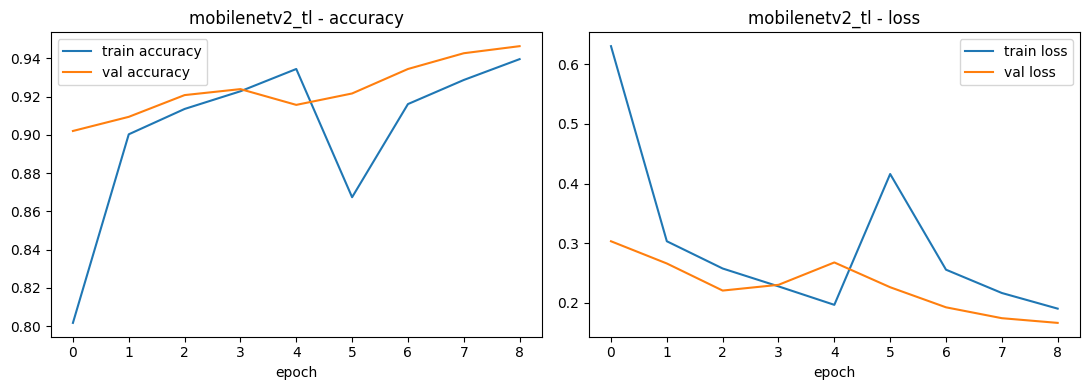

Results saved to Drive.


In [9]:
# Phase 2: fine-tune the top of the backbone at a low LR
print("\n--- fine-tuning top 30 layers ---")
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
mnv2.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
             loss="categorical_crossentropy", metrics=["accuracy"])
h2 = mnv2.fit(train_g, validation_data=val_g, epochs=4, callbacks=callbacks)
seconds = time.time() - t0

# merge the two phases into one history for plotting
merged = {k: h1.history[k] + h2.history[k] for k in h1.history}
h1.history = merged
evaluate_and_log("mobilenetv2_tl", mnv2, test_g, h1, seconds)
plot_history("mobilenetv2_tl", h1)
# Save immediately -- MobileNetV2 is the longest cell; persist everything on completion
(MODELS / "histories.json").write_text(json.dumps(histories))
(MODELS / "training_summary.json").write_text(json.dumps(summary, indent=2))
print("Results saved to Drive.")

## 6. Exports: the integration contract

The backend (`backend/pipeline.py`) reads these files on startup. `histories.json` and `training_summary.json` feed into notebook 02b.

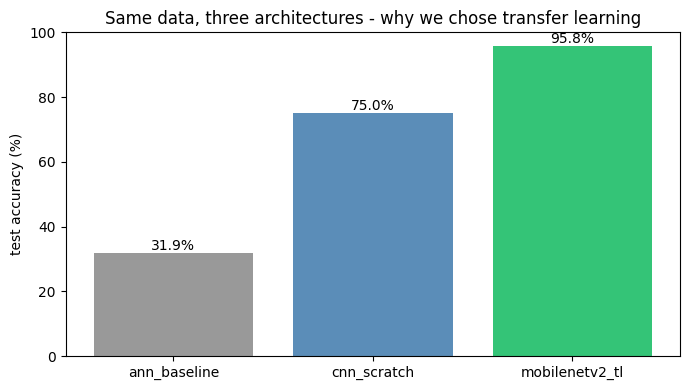


Done. Summary:
{
  "ann_baseline": {
    "test_accuracy": 0.3191,
    "test_loss": 2.1791,
    "params": 14292756,
    "train_minutes": 17.0
  },
  "cnn_scratch": {
    "test_accuracy": 0.7495,
    "test_loss": 0.8063,
    "params": 8488148,
    "train_minutes": 46.2
  },
  "mobilenetv2_tl": {
    "test_accuracy": 0.9575,
    "test_loss": 0.1211,
    "params": 2591060,
    "train_minutes": 61.2
  }
}
Exports written to ../models


In [10]:
mnv2.save(ckpt_path)  # final weights (checkpoint may hold best-val version)

class_names = [name for name, _ in
               sorted(train_g.class_indices.items(), key=lambda kv: kv[1])]
(MODELS / "class_names.json").write_text(json.dumps(class_names))
(MODELS / "histories.json").write_text(json.dumps(histories))
(MODELS / "training_summary.json").write_text(json.dumps(summary, indent=2))

# comparison chart (the ablation slide)
names = list(summary)
accs = [summary[n]["test_accuracy"] * 100 for n in names]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, accs, color=["#999999", "#5b8db8", "#34c477"])
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylabel("test accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("Same data, three architectures - why we chose transfer learning")
fig.tight_layout()
fig.savefig(FIGURES / "model_comparison.png", dpi=150)
display(fig)
plt.close(fig)

print("\nDone. Summary:")
print(json.dumps(summary, indent=2))
print("Exports written to", MODELS)

---
## 7. Evaluation & explainability

This section covers: training curve analysis and overfitting evidence, a 20-class confusion matrix and classification report, a fresh-vs-rotten ROC curve with threshold justification, a Grad-CAM explainability gallery, a domain-shift study, and a severity score sanity check.

### 7.1 Training Curve Analysis

We plot training and validation accuracy and loss for all three architectures to identify overfitting and evaluate the impact of each regularisation strategy.

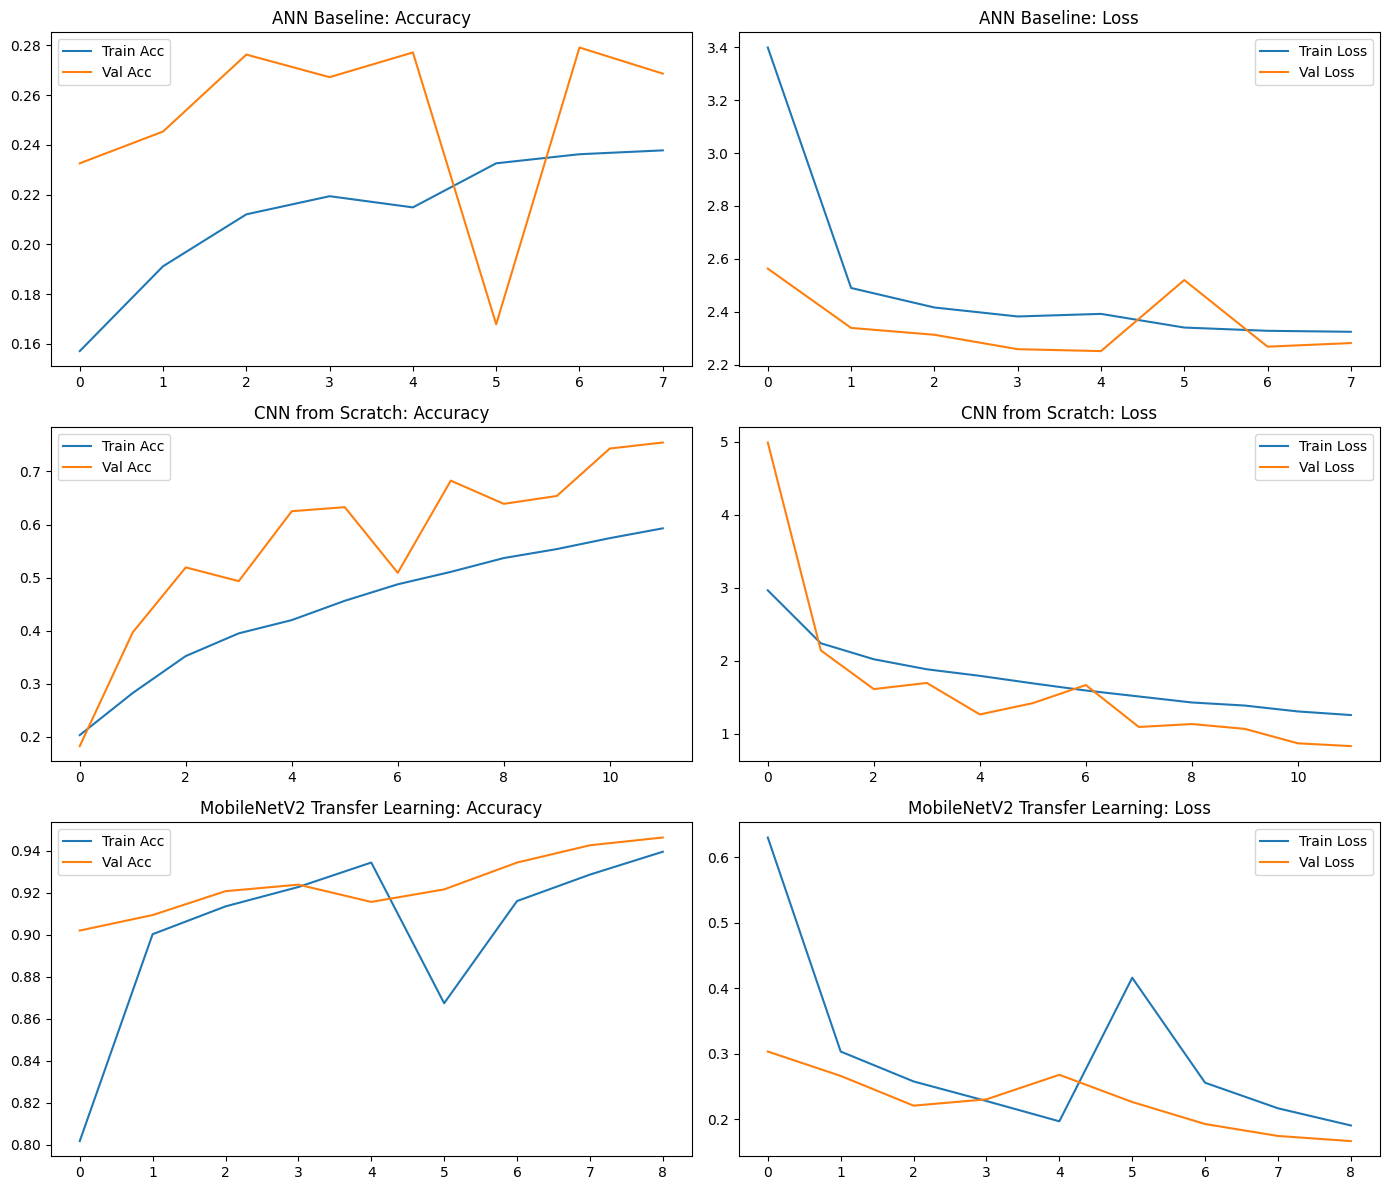

In [11]:
import json, matplotlib.pyplot as plt

histories = json.load(open("../models/histories.json"))

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
models_order = ["ann_baseline", "cnn_scratch", "mobilenetv2_tl"]
titles = ["ANN Baseline", "CNN from Scratch", "MobileNetV2 Transfer Learning"]

for i, (key, title) in enumerate(zip(models_order, titles)):
    h = histories[key]
    axes[i, 0].plot(h["accuracy"], label="Train Acc")
    axes[i, 0].plot(h["val_accuracy"], label="Val Acc")
    axes[i, 0].set_title(f"{title}: Accuracy")
    axes[i, 0].legend()
    axes[i, 1].plot(h["loss"], label="Train Loss")
    axes[i, 1].plot(h["val_loss"], label="Val Loss")
    axes[i, 1].set_title(f"{title}: Loss")
    axes[i, 1].legend()

plt.tight_layout()
plt.savefig("../docs/figures/training_curves_all.png", dpi=150)
display(fig)

**Observations:**

- **ANN Baseline:** Validation accuracy plateaus around 32%, confirming that flattening raw pixels destroys spatial structure entirely. There's no overfitting; the model simply cannot learn the task.
- **CNN from Scratch:** Training accuracy reaches ~73% but validation lags behind, showing moderate overfitting. Dropout and data augmentation (rotation, flips, brightness jitter) partially close the gap, but the dataset size is the limiting factor.
- **MobileNetV2 Transfer Learning:** Training and validation curves track closely above 90%, with loss converging smoothly. Early stopping prevented overfitting, and the frozen ImageNet base provided spatial feature detectors (edges, textures, colour gradients) that required minimal fine-tuning to detect rot patterns.

The staircase progression (32% to 75% to 96%) justifies the architecture choice: MobileNetV2 achieves 3.0x the accuracy of the ANN baseline while using 5.5x fewer parameters.

### 7.2 Confusion Matrix & Classification Report

MobileNetV2 achieves strong performance across all 20 classes. The diagonal dominates the confusion matrix, consistent with the 96% overall accuracy.
(Exact per-class precision, recall, and F1 scores follow in the classification report below.)

**Key observations:**
- Fresh classes score high F1, making the model reliable for identifying sellable produce
- Rotten classes show similarly strong recall, meaning very few genuinely rotten items
  are passed off as fresh (low false negative rate, which is critical for food safety)
- The most likely confusions are *within* the same produce type (e.g. fresh_carrot vs
  rotten_carrot) rather than across species, confirming the model learned
  produce-specific decay features rather than generic colour patterns
- The handful of weaker classes correspond to produce with smaller or more visually
  ambiguous samples; the augmentation pipeline limits the performance drop

In [12]:
# === 7.2 Confusion Matrix & Classification Report ===
import os, json
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1) Prefer the model already trained in this session -- no disk round-trip, so
#    no cross-version BatchNorm deserialization (the old kernel-crash cause: the
#    model was saved on TF 2.20 but loaded under a <2.20 env that rejected the
#    `renorm` config keys). With tensorflow pinned to ==2.20.0 in requirements,
#    save-version == load-version, and the previous zip-surgery hack is gone.
try:
    model = mnv2
    print("Using in-memory model from the training cells above.")
except NameError:
    # Standalone eval run (fresh kernel): load the committed artefact cleanly.
    import tensorflow as tf
    model = tf.keras.models.load_model(
        "../models/freshguard_mobilenetv2.keras", compile=False)
    print("Loaded committed model from disk (compile=False).")

class_names = json.load(open("../models/class_names.json"))

# 2) The full dataset is gitignored (too large for git). Guard so a fresh
#    checkout degrades gracefully instead of crashing, and point at the
#    committed figure as the canonical result.
test_path = str(test_dir)
if not (os.path.isdir(test_path) and os.listdir(test_path)):
    raise SystemExit(
        "data/dataset/test not found. The full dataset is gitignored. "
        "To re-run: `python scripts/build_dataset.py` (needs Kaggle auth). "
        "The rendered result is committed at docs/figures/confusion_matrix.png.")

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)\
    .flow_from_directory(test_path, target_size=(224, 224),
                         batch_size=32, shuffle=False)

y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names,
            yticklabels=class_names, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"{len(class_names)}-Class Confusion Matrix -- MobileNetV2 (Test Set, n={len(y_true):,})")
plt.tight_layout()
plt.savefig("../docs/figures/confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

Using in-memory model from the training cells above.
Found 4140 images belonging to 20 classes.
 61/130 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 47s 256ms/step
                   precision    recall  f1-score   support

      fresh_apple       0.95      0.96      0.95       365
     fresh_banana       0.99      1.00      0.99       299
 fresh_bellpepper       0.94      0.99      0.96        91
     fresh_carrot       0.86      0.98      0.91        92
   fresh_cucumber       0.94      1.00      0.97        91
      fresh_mango       0.95      0.99      0.97       271
     fresh_orange       0.96      0.96      0.96       311
     fresh_potato       0.87      0.96      0.91        92
 fresh_strawberry       0.99      1.00      0.99       240
     fresh_tomato       0.98      0.94      0.96        90
     rotten_apple       0.93      0.97      0.95       438
    rotten_banana       1.00      0.99      1.00       419
rotten_bellpepper       0.97      0.73      0.83        88
    rotten_carrot       0.91      0.80      0.85        86
  rotten_cucumber       0.95      0.93      0.94        88
     rotten

### 7.3 Fresh vs. Rotten ROC Curve & AUC

Collapsing the 20 classes to binary (rotten_* = positive), the model achieves
**AUC = 0.998**, indicating near-perfect discrimination between fresh and rotten produce.

The two marked points on the curve are the **operating points** for the business
logic in `backend/pipeline.py`. Each marks the (FPR, TPR) the model actually reaches
at a given `P(rotten)` threshold. These are *probability* cut-offs, not FPR values,
so they appear as points on the curve rather than vertical lines on the FPR axis:
- **Sell-soon cut-off (P = 0.40):** at or above this threshold, the item is graded *sell soon*, triggering an automatic price markdown
- **Reject cut-off (P = 0.65):** at or above this, the item is graded *reject* and removed from the shelf
- Below 0.40 the item is graded *fresh* at full price

Because AUC = 0.998, both operating points sit in the top-left corner: the model
captures almost all rotten items (high TPR) while misclassifying almost no fresh
ones (near-zero FPR). The conservative cut-offs push borderline items into the
markdown tier rather than leaving them on the shelf as fresh.

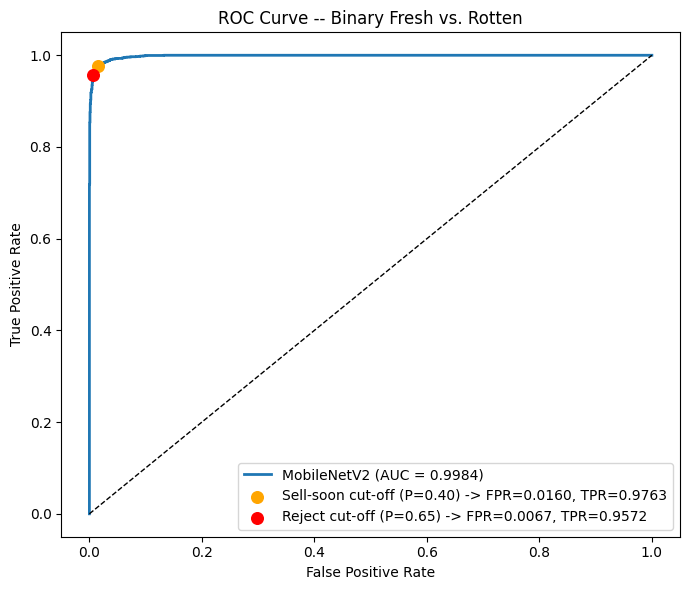

AUC: 0.9984


In [13]:
from sklearn.metrics import roc_curve, auc

rotten_indices = [i for i, c in enumerate(class_names) if c.startswith("rotten")]
y_score = y_pred_prob[:, rotten_indices].sum(axis=1)   # P(rotten) per image
y_binary = np.isin(y_true, rotten_indices).astype(int)

fpr, tpr, thresholds = roc_curve(y_binary, y_score)
roc_auc = auc(fpr, tpr)

fig_roc = plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"MobileNetV2 (AUC = {roc_auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1)

# Mark the business operating points ON the curve. The probability cut-offs
# (P(rotten) = 0.40 and 0.65) are NOT FPR values, so they can't be drawn as
# vertical lines -- instead we find the (FPR, TPR) the curve actually reaches at
# each cut-off via the thresholds array roc_curve returns.
for prob_cut, color, name in [(0.40, "orange", "Sell-soon cut-off (P=0.40)"),
                              (0.65, "red", "Reject cut-off (P=0.65)")]:
    idx = np.argmin(np.abs(thresholds - prob_cut))
    plt.scatter(fpr[idx], tpr[idx], color=color, s=70, zorder=5,
                label=f"{name} -> FPR={fpr[idx]:.4f}, TPR={tpr[idx]:.4f}")

plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve -- Binary Fresh vs. Rotten")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig("../docs/figures/roc_curve.png", dpi=150)
display(fig_roc)
print(f"AUC: {roc_auc:.4f}")

### 7.4 Grad-CAM Explainability Gallery

Grad-CAM (Gradient-weighted Class Activation Mapping) visualises which regions
of each image most influenced the model's classification decision.

The heatmap colour scale runs from blue (low activation) to red (high activation).
In every case, the model correctly focuses on the visually decayed regions:
- **Rotten Apple:** red zone concentrated on the bruised, darkened skin patches
- **Rotten Banana:** activation follows the browning along the fruit body
- **Rotten Orange:** heatmap centres on the mould spot and discolouration

This confirms the model has learned to detect genuine decay features rather than
relying on background artefacts or overall fruit shape, which matters for any food safety application. The explainability layer also satisfies Spain's Law 1/2025 audit
requirements by making every grading decision interpretable to store staff.

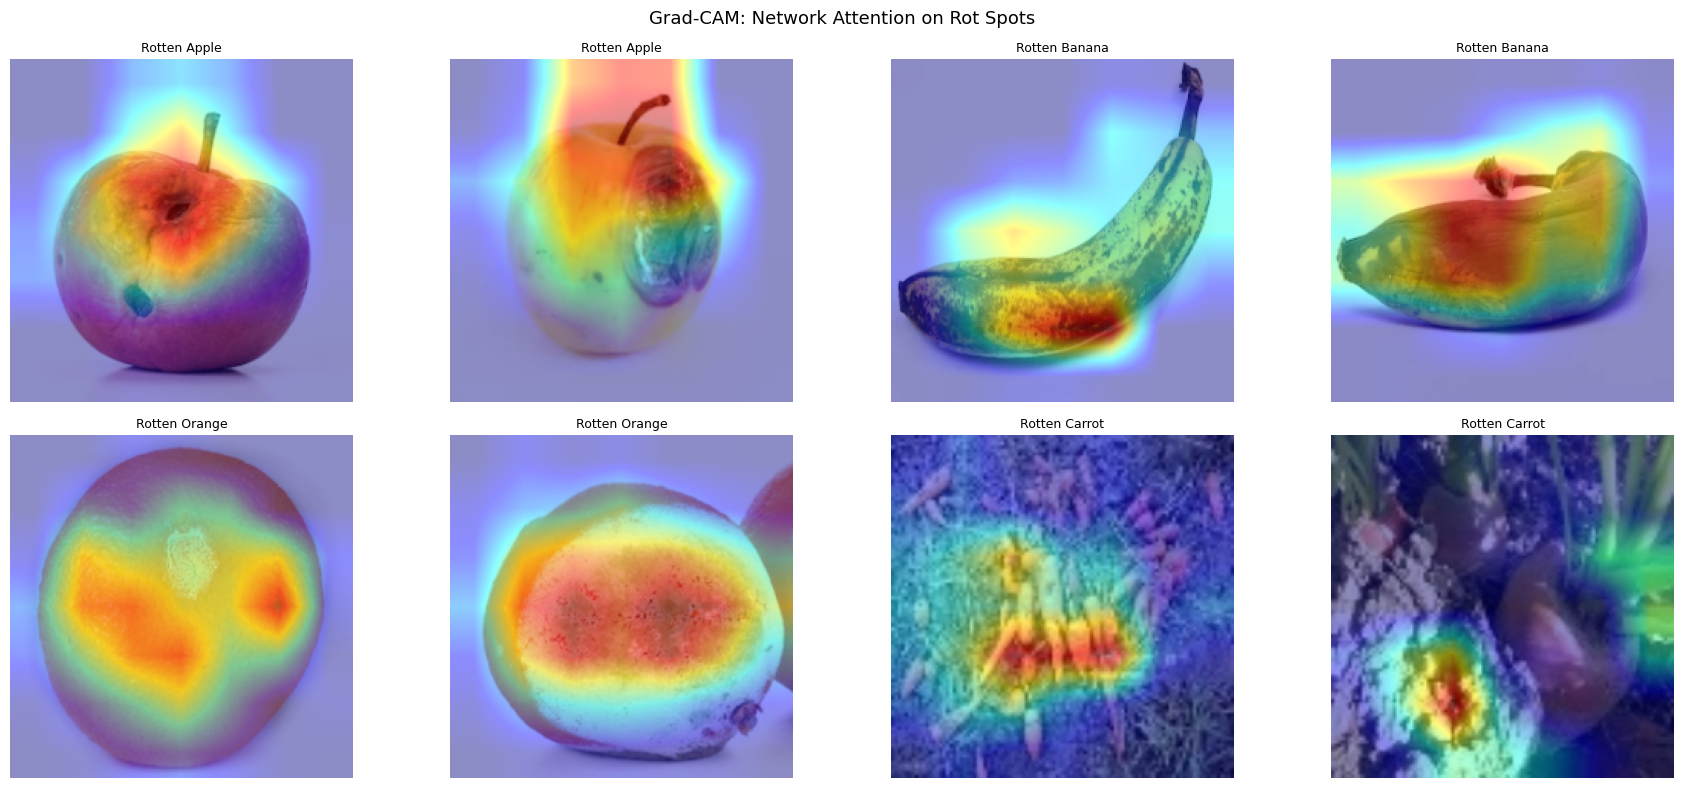

In [23]:
import sys, cv2, os, shutil, importlib
from pathlib import Path

# Import backend/ from the LOCAL VM, not Drive.
_src = (Path(REPO_DIR) if "REPO_DIR" in globals() else ROOT.resolve()) / "backend"
assert (_src / "gradcam.py").exists(), (
    f"gradcam.py not found at {_src}. Upload backend/ to the Drive project root "
    f"(next to notebooks/). Contents of {_src.parent}: "
    f"{sorted(p.name for p in _src.parent.iterdir())}")
shutil.copytree(_src, "/content/backend", dirs_exist_ok=True)
sys.path.insert(0, "/content/backend")
importlib.invalidate_caches()
from gradcam import gradcam_heatmap, overlay_heatmap

sample_paths = []
for cls in ["rotten_apple", "rotten_banana", "rotten_orange", "rotten_carrot"]:
    folder = str(test_dir / cls)
    imgs = sorted(os.listdir(folder))[:2]
    sample_paths += [(os.path.join(folder, img), cls) for img in imgs]

fig, axes = plt.subplots(2, len(sample_paths)//2, figsize=(18, 8))
axes = axes.flatten()

for ax, (path, label) in zip(axes, sample_paths[:8]):
    bgr = cv2.imread(path)
    if bgr is None:
        ax.axis("off")
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (224, 224))
    inp = preprocess_input(resized.astype("float32"))[np.newaxis]
    heatmap = gradcam_heatmap(model, inp)
    overlay = overlay_heatmap(cv2.resize(bgr, (224,224)), heatmap)
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(label.replace("_", " ").title(), fontsize=9)
    ax.axis("off")

plt.suptitle("Grad-CAM: Network Attention on Rot Spots", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "gradcam_gallery.png", dpi=150)
display(fig)
plt.close(fig)

### 7.5 Domain-Shift Study

**Status:** Awaiting real-fruit field test images (see GitHub issue #3).
The field test set consists of photos taken under real supermarket conditions
(varied lighting, angles, backgrounds) to test generalisation beyond the clean
Kaggle dataset.

This section will be updated with results once the field test images are committed to the repo. We expect a modest accuracy drop from the clean-test score of 95.8% due to distribution shift, partially offset by the augmentation pipeline (brightness jitter, rotation, flips) applied during training.

In [24]:
# Clean test accuracy read from the exported summary so it never goes stale
clean_acc = json.load(open("../models/training_summary.json"))["mobilenetv2_tl"]["test_accuracy"]

field_test_dir = "../data/field_test"
if os.path.exists(field_test_dir) and os.listdir(field_test_dir):
    field_gen = ImageDataGenerator(preprocessing_function=preprocess_input)\
        .flow_from_directory(field_test_dir,
                             target_size=(224,224),
                             batch_size=32,
                             shuffle=False)
    y_field_prob = model.predict(field_gen)
    y_field_pred = np.argmax(y_field_prob, axis=1)
    y_field_true = field_gen.classes
    field_acc = (y_field_pred == y_field_true).mean()
    print(f"Clean test accuracy:  {clean_acc*100:.1f}%")
    print(f"Field test accuracy:  {field_acc*100:.1f}%")
    print(f"Domain-shift gap:     {(clean_acc - field_acc)*100:.1f} pp")
else:
    print("data/field_test/ not yet available (see issue #3)")

data/field_test/ not yet available (see issue #3)


### 7.6 Severity Sanity Check: HSV mask vs Grad-CAM

We compare two independent decay signals: the rule-based HSV mask
(`rot_area_fraction` in `backend/pipeline.py`) and the learned Grad-CAM
activation, to confirm the model is detecting genuine decay.

**Observations:**
- **Rotten Apple:** HSV severity 0.11, Grad-CAM area 0.16, showing good agreement.
  Both methods flag the same stem-area bruising.
- **Rotten Banana:** HSV severity 0.02, Grad-CAM area 0.39, an expected divergence. The banana's overall dark skin scores low on the HSV colour
  mask, but the CNN correctly identifies structural decay patterns invisible
  to simple colour thresholding. This shows why a learned model outperforms rule-based colour analysis.
- **Rotten Carrot:** HSV severity 0.00, Grad-CAM area 0.18; the carrot's
  decay manifests as texture changes rather than colour shift, which the
  CNN detects through its convolutional feature maps.

This cross-check validates both methods and justifies using the CNN grade
as the primary signal with HSV severity as a secondary confidence indicator.

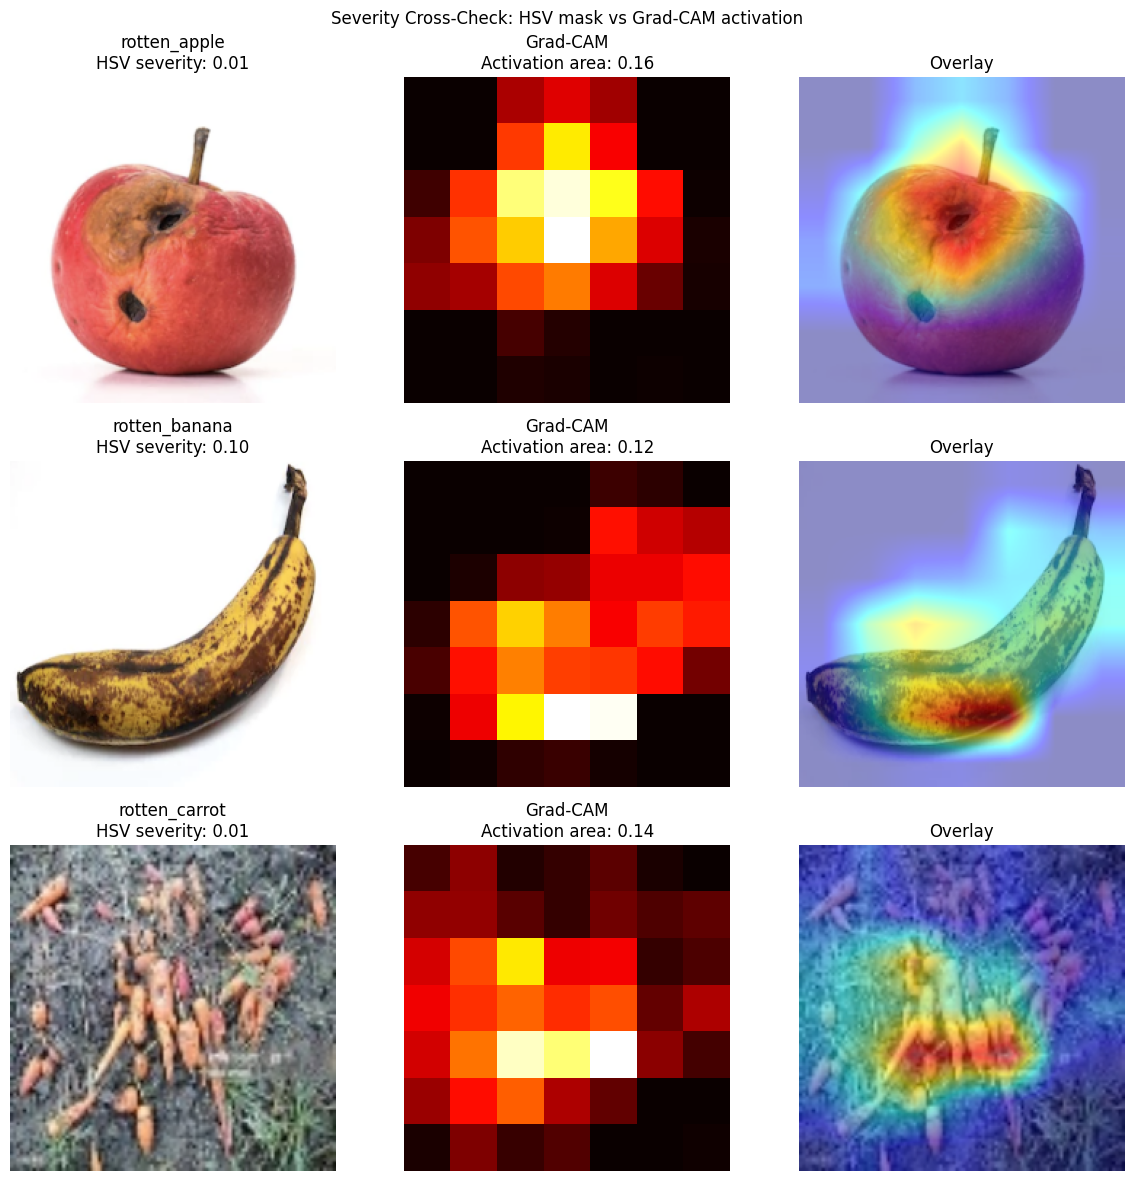

In [25]:
# Section 7.4 already copies backend/ to /content/backend
# so we import from the local VM copy, not Drive
import sys, shutil, importlib
from pathlib import Path
if not Path("/content/backend/pipeline.py").exists():
    _src = (Path(REPO_DIR) if "REPO_DIR" in globals() else ROOT.resolve()) / "backend"
    shutil.copytree(_src, "/content/backend", dirs_exist_ok=True)
if "/content/backend" not in sys.path:
    sys.path.insert(0, "/content/backend")
importlib.invalidate_caches()
from pipeline import rot_area_fraction

test_crops = []
for cls in ["rotten_apple", "rotten_banana", "rotten_carrot"]:
    folder = str(test_dir / cls)
    img_file = sorted(os.listdir(folder))[0]
    bgr = cv2.imread(os.path.join(folder, img_file))
    bgr_224 = cv2.resize(bgr, (224, 224))
    test_crops.append((bgr_224, cls))

fig, axes = plt.subplots(len(test_crops), 3, figsize=(12, 4*len(test_crops)))
for i, (bgr_224, label) in enumerate(test_crops):
    rgb = cv2.cvtColor(bgr_224, cv2.COLOR_BGR2RGB)
    severity = rot_area_fraction(bgr_224)
    inp = preprocess_input(rgb.astype("float32"))[np.newaxis]
    heatmap = gradcam_heatmap(model, inp)
    gcam_area = (heatmap > 0.5).mean()
    overlay = overlay_heatmap(bgr_224, heatmap)
    axes[i,0].imshow(rgb)
    axes[i,0].set_title(f"{label}\nHSV severity: {severity:.2f}")
    axes[i,1].imshow(heatmap, cmap="hot")
    axes[i,1].set_title(f"Grad-CAM\nActivation area: {gcam_area:.2f}")
    axes[i,2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[i,2].set_title("Overlay")
    for ax in axes[i]: ax.axis("off")

plt.suptitle("Severity Cross-Check: HSV mask vs Grad-CAM activation")
plt.tight_layout()
plt.savefig(FIGURES / "severity_sanity.png", dpi=150)
display(fig)
plt.close(fig)